# Section 8 - regime 1 (CelebA) - V2 P-scaling - Compare Results

Does adding capacity (P) raise accuracy, and does forward-only three-factor resist the overfitting backprop shows? Four runs at equal wall-clock: three-factor @ 1M/10M/25M vs backprop @ 500M.

## 1. Setup + Load Results

In [1]:
import os, json, math, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
device='cuda' if torch.cuda.is_available() else 'cpu'
USE_DRIVE, DRIVE_SUBDIR = True, 'Section8_r1_celeba_v2'
if USE_DRIVE:
    try:
        from google.colab import drive; drive.mount('/content/drive'); STORE=os.path.join('/content/drive/MyDrive',DRIVE_SUBDIR)
    except Exception as e:
        print('Drive mount failed:',e); STORE=os.path.join('/content',DRIVE_SUBDIR)
else:
    STORE=os.path.join('.',DRIVE_SUBDIR)
RESULTS_DIR=os.path.join(STORE,'results'); CKPT_DIR=os.path.join(STORE,'checkpoints')
# OPTIONAL: to overlay the already-completed backprop@1M / backprop_100M on the P-curve (no new runs),
# export their JSONs from Section8_r1_celeba/results, drop that folder here, and add the keys to METHODS.
EXTRA_RESULTS_DIRS = []
EXTRA_CKPT_DIRS    = []
METHODS=['three_factor_supernoisy_1M','three_factor_noisy_10M','three_factor_noisy_25M','backprop_500M']
LABELS={'three_factor_supernoisy_1M':'3-factor super-noisy - 1M',
        'three_factor_noisy_10M':'3-factor noisy - 10M',
        'three_factor_noisy_25M':'3-factor noisy - 25M',
        'backprop_500M':'Backprop - 500M'}
COLORS={'three_factor_supernoisy_1M':'#E67E22','three_factor_noisy_10M':'#C62828',
        'three_factor_noisy_25M':'#7B1FA2','backprop_500M':'#1F3864'}
def _find(m):
    for d in [RESULTS_DIR]+EXTRA_RESULTS_DIRS:
        p=os.path.join(d,f'{m}.json')
        if os.path.exists(p): return p
    return None
R={}
for m in METHODS:
    p=_find(m)
    if p:
        R[m]=json.load(open(p)); s=R[m]['summary']; md=R[m]['meta']
        print(f'loaded {m:28} P={md["P"]:>12,}  {md["total_steps"]:>9,} steps  {md["wall_clock_sec"]/3600:5.2f}h  best BCE {s["best_loss"]:.4f}  best acc {s["best_acc"]:.4f}')
    else:
        print(f'MISSING {m}.json (run the {m} notebook first)')

Mounted at /content/drive
loaded backprop                   685,375 steps   2.00h  best BCE 0.2603  best mean-attr-acc 0.8878
loaded two_factor                 847,168 steps   2.00h  best BCE 0.7061  best mean-attr-acc 0.7747
loaded three_factor_clean               7 steps   2.16h  best BCE 0.4515  best mean-attr-acc 0.8015
loaded three_factor_normal            265 steps   2.01h  best BCE 0.4219  best mean-attr-acc 0.8092
loaded three_factor_noisy          20,732 steps   2.00h  best BCE 0.3463  best mean-attr-acc 0.8520
loaded backprop_100M               36,599 steps   2.00h  best BCE 0.2728  best mean-attr-acc 0.8804


## (optional) merge results from another account

In [2]:
# --- OPTIONAL: merge results exported from ANOTHER Google account (upload <method>.json / .pt) ---
import os
try:
    from google.colab import files
    up = files.upload(); import shutil
    for fn in up:
        dst = '/content/extra_results' if fn.endswith('.json') else '/content/extra_ckpts'
        os.makedirs(dst, exist_ok=True); shutil.move(fn, os.path.join(dst, fn))
    if os.path.isdir('/content/extra_results') and '/content/extra_results' not in EXTRA_RESULTS_DIRS:
        EXTRA_RESULTS_DIRS.append('/content/extra_results')
    if os.path.isdir('/content/extra_ckpts') and '/content/extra_ckpts' not in EXTRA_CKPT_DIRS:
        EXTRA_CKPT_DIRS.append('/content/extra_ckpts')
    print('re-run the load cell above; EXTRA_RESULTS_DIRS =', EXTRA_RESULTS_DIRS)
except Exception as e:
    print('nothing uploaded (fine if all results are on this Drive):', e)

re-run the load cell above; EXTRA_RESULTS_DIRS = []


## 2. Compare curves (BCE + mean-attr accuracy)

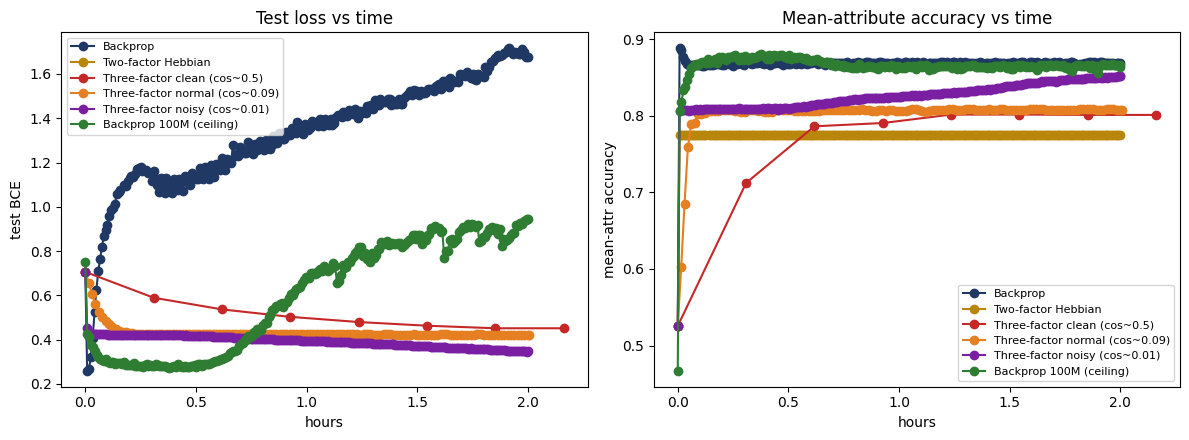

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for m in R:
    c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
    ax[0].plot(hrs, c['test_loss'], 'o-', color=COLORS[m], label=LABELS[m])
    ax[1].plot(hrs, c['test_acc'],  'o-', color=COLORS[m], label=LABELS[m])
ax[0].set_xlabel('hours'); ax[0].set_ylabel('test BCE'); ax[0].set_title('Test loss vs time'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('hours'); ax[1].set_ylabel('mean-attr accuracy'); ax[1].set_title('Mean-attribute accuracy vs time'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Cost & Memory

In [4]:
def fwd_equiv(m):
    st = R[m]['meta']['total_steps']
    if m.startswith('three_factor'): return st * 2 * R[m]['meta']['config'].get('M', 0)
    if m.startswith('backprop'): return st * 3
    return st * 2
print(f'{"method":30}{"steps":>10}{"fwd-equiv":>14}{"wall h":>8}{"peak MB":>9}')
print('-'*71)
for m in R:
    md = R[m]['meta']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{fwd_equiv(m):>14,}{md["wall_clock_sec"]/3600:>8.2f}{md.get("peak_mem_mb", float("nan")):>9.1f}')

method                             steps     fwd-equiv  wall h  peak MB
-----------------------------------------------------------------------
Backprop                         685,375     2,056,125    2.00   3296.9
Two-factor Hebbian               847,168     1,694,336    2.00   6393.6
Three-factor clean (cos~0.5)           7     4,909,296    2.16   5350.0
Three-factor normal (cos~0.09)       265     4,553,230    2.01   4525.1
Three-factor noisy (cos~0.01)     20,732     4,353,720    2.00   4520.3
Backprop 100M (ceiling)           36,599       109,797    2.00   6025.0


## 4. Accuracy & overfitting vs capacity (P)

In [ ]:
# --- V2 headline: accuracy & best test-BCE vs capacity (P), all at equal wall-clock ---
order = [m for m in METHODS if m in R]
if order:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
    tf = [m for m in order if m.startswith('three_factor')]
    bp = [m for m in order if m.startswith('backprop')]
    if tf:
        ax[0].plot([R[m]['meta']['P'] for m in tf], [R[m]['summary']['best_acc'] for m in tf],
                   'o-', color='#7B1FA2', label='three-factor (forward-only)')
    for m in bp:
        ax[0].scatter([R[m]['meta']['P']], [R[m]['summary']['best_acc']], color='#1F3864', zorder=5,
                      label=('backprop' if m == bp[0] else None))
    for m in order:
        ax[0].annotate(LABELS[m], (R[m]['meta']['P'], R[m]['summary']['best_acc']),
                       fontsize=7, xytext=(4, 4), textcoords='offset points')
    ax[0].set_xscale('log'); ax[0].set_xlabel('parameters P (log scale)')
    ax[0].set_ylabel('best mean-attr accuracy'); ax[0].set_title('Accuracy vs capacity (equal wall-clock)')
    ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
    if tf:
        ax[1].plot([R[m]['meta']['P'] for m in tf], [R[m]['summary']['best_loss'] for m in tf],
                   'o-', color='#7B1FA2', label='three-factor')
    for m in bp:
        ax[1].scatter([R[m]['meta']['P']], [R[m]['summary']['best_loss']], color='#1F3864', zorder=5,
                      label=('backprop' if m == bp[0] else None))
    ax[1].set_xscale('log'); ax[1].set_xlabel('parameters P (log scale)')
    ax[1].set_ylabel('best test BCE'); ax[1].set_title('Best test loss vs capacity')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('no results loaded yet')

In [ ]:
# --- Overfitting view: train (dashed) vs test (solid) BCE over time, and the generalization gap ---
order = [m for m in METHODS if m in R]
if order:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
    for m in order:
        c = R[m]['curve']; hrs = [t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'],  '-',  color=COLORS[m], label=LABELS[m])
        ax[0].plot(hrs, c['train_loss'], '--', color=COLORS[m], alpha=0.7)
        gap = [te - tr for te, tr in zip(c['test_loss'], c['train_loss'])]
        ax[1].plot(hrs, gap, 'o-', color=COLORS[m], label=LABELS[m])
    ax[0].set_xlabel('hours'); ax[0].set_ylabel('BCE')
    ax[0].set_title('Train (dashed) vs test (solid) BCE'); ax[0].legend(fontsize=7); ax[0].grid(alpha=0.3)
    ax[1].axhline(0, color='k', lw=0.6)
    ax[1].set_xlabel('hours'); ax[1].set_ylabel('test - train BCE (overfit gap)')
    ax[1].set_title('Generalization gap vs time'); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print('Reading: backprop@500M overfits => train BCE dives below test BCE (positive, widening gap).')
    print('three-factor: gap stays small (slow/underfit), more so at higher P (lower realized cos).')
else:
    print('no results loaded yet')

## 6. Summary table

In [8]:
print(f'{"Experiment":30}{"Steps":>10}{"Init BCE":>10}{"Best BCE":>10}{"Final acc":>11}{"Best acc":>10}')
print('-'*81)
for m in R:
    md, s = R[m]['meta'], R[m]['summary']
    print(f'{LABELS[m]:30}{md["total_steps"]:>10,}{s["initial_loss"]:>10.4f}{s["best_loss"]:>10.4f}{s["final_acc"]:>11.4f}{s["best_acc"]:>10.4f}')

Experiment                         Steps  Init BCE  Best BCE  Final acc  Best acc
---------------------------------------------------------------------------------
Backprop                         685,375    0.7061    0.2603     0.8685    0.8878
Two-factor Hebbian               847,168    0.7061    0.7061     0.7747    0.7747
Three-factor clean (cos~0.5)           7    0.7061    0.4515     0.8010    0.8015
Three-factor normal (cos~0.09)       265    0.7061    0.4219     0.8072    0.8092
Three-factor noisy (cos~0.01)     20,732    0.7061    0.3463     0.8520    0.8520
Backprop 100M (ceiling)           36,599    0.7514    0.2728     0.8658    0.8804


## 7. Export figures + CSV → Drive

In [9]:
# Export figures (PNG) + data (CSV) -> a Drive folder, then download a zip.
import os, csv, glob, shutil
EXPORT_DIR = os.path.join(STORE, 'exports'); os.makedirs(EXPORT_DIR, exist_ok=True)
if R:
    ckeys = []
    for m in R:
        for k in R[m]['curve']:
            if k not in ckeys: ckeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'curves.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method'] + ckeys)
        for m in R:
            c = R[m]['curve']; n = len(c.get('t_sec', []))
            for i in range(n): w.writerow([m] + [c[k][i] if (k in c and i < len(c[k])) else '' for k in ckeys])
    skeys = []
    for m in R:
        for k in R[m]['summary']:
            if k not in skeys: skeys.append(k)
    with open(os.path.join(EXPORT_DIR, 'summary.csv'), 'w', newline='') as f:
        w = csv.writer(f); w.writerow(['method','P','total_steps','wall_clock_h','M','cos'] + skeys)
        for m in R:
            md, s = R[m]['meta'], R[m]['summary']; M = md['config'].get('M') or 0
            cos = round((M/(M+md['P']+1))**0.5, 4) if M else ''
            w.writerow([m, md['P'], md['total_steps'], round(md['wall_clock_sec']/3600,3), M, cos] + [s.get(k,'') for k in skeys])
    print('wrote curves.csv, summary.csv')
def _save(fig, name): fig.savefig(os.path.join(EXPORT_DIR, name), dpi=130, bbox_inches='tight'); plt.close(fig)
if R:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
    for m in R:
        c = R[m]['curve']; hrs=[t/3600 for t in c['t_sec']]
        ax[0].plot(hrs, c['test_loss'],'o-',color=COLORS[m],label=LABELS[m])
        ax[1].plot(hrs, c['test_acc'],'o-',color=COLORS[m],label=LABELS[m])
    ax[0].set_ylabel('test BCE'); ax[1].set_ylabel('mean-attr acc')
    for a in ax: a.set_xlabel('hours'); a.legend(fontsize=8)
    _save(fig, 'curves_bce_acc.png'); print('wrote comparison figure')
for d in {RESULTS_DIR, CKPT_DIR, STORE}:
    for png in glob.glob(os.path.join(d, '*.png')):
        try: shutil.copy(png, EXPORT_DIR)
        except Exception: pass
print('\nexport folder:', EXPORT_DIR); print(' ', sorted(os.listdir(EXPORT_DIR)))
_zt = '/content' if os.path.isdir('/content') else os.path.dirname(EXPORT_DIR)
zip_path = shutil.make_archive(os.path.join(_zt, DRIVE_SUBDIR + '_exports'), 'zip', EXPORT_DIR)
try:
    if os.path.abspath(os.path.dirname(zip_path)) != os.path.abspath(STORE): shutil.copy(zip_path, STORE)
except Exception as e: print('(could not copy zip to Drive):', e)
print('zip:', zip_path)
try:
    from google.colab import files; files.download(zip_path)
except Exception as e:
    print('(download only runs in Colab):', e)

wrote curves.csv, summary.csv
wrote comparison figure

export folder: /content/drive/MyDrive/Section8_r1_celeba/exports
  ['curves.csv', 'curves_bce_acc.png', 'summary.csv']
zip: /content/Section8_r1_celeba_exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>